# Patching code automation

This code relies on the slice images and masks being in a folder called `testing_slices/`

Inside that folder, create a folder called `patch_outputs/` for the patches to be exported into

## Setup

In [972]:
import numpy as np
import cv2
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
import pandas as pd
import csv
from scipy.ndimage import gaussian_filter1d


In [973]:
extension_factor = 1.1; 
step_size = 2;
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2

## Read in testing folder

In [974]:
import os
image_folder = './testing_slices'
image_files = [f for f in os.listdir(image_folder) if f.startswith('h&e')]

## Patching code function

In [975]:
def get_contours(binary_image):
    '''find all ext`ernal contours of an image'''

    contours,hierarchy=cv2.findContours(binary_image,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    #This can be used to alter the order contour points are processed in while maintaining order
        #Think [1,2,3,4,5]->[4,5,1,2,3]
        #Set to 0 for no effect, check np documentation for more info
    return [np.roll(contour,0,axis=0) for contour in contours]


def better_normals(contours,binary_image):
    #Initialize list for final normals
    all_normals=[]

    #Loop through all contours
    for contour in contours:
        #Reshape contour into point pairings
        points=contour.reshape(-1,2).astype(np.float32)
        
        #Store all X and Y points
        x_all,y_all=points[:,0],points[:,1]
        #Define sigma paramter(std for Gaussian Kernel from contour length)
        #Higher value of sigma means more aggressive smoothing
        sigma=len(contour)//90
        
        #Avoid dividing by 0
        if sigma==0:
            sigma=1

        #Apply Gaussian smoothing to X and Y values, attempting to remove noise from the contour
        x_smooth=gaussian_filter1d(x_all,sigma,mode='constant')
        y_smooth=gaussian_filter1d(y_all,sigma,mode='constant')

        #Calculate gradients of X and Y for use then finding the tangent
        dx=np.gradient(x_smooth)
        dy=np.gradient(y_smooth)


        #Combine the gradients for the tangent
        tangents=np.vstack((dx,dy)).T
        #Find vector norms of tangent vectors
        norms = np.linalg.norm(tangents, axis=1, keepdims=True)
        #Divide tangents by norms with numerical stability
        tangent_unit = tangents/(norms+1e-8)
        #Initialize normals
        normals=np.zeros_like(tangent_unit)
        #Rotate tangents into normals
        normals[:,0]=-tangent_unit[:,1]
        normals[:,1]=tangent_unit[:,0]

        all_normals.append(normals)

    return all_normals

def calculate_patch_corners(point, normal, binary_image, extension_factor=1.0, step_size=4, max_length=2048):
    """
    Calculate the corners of a square patch using epithelium width along the normal.

    Args:
        point (np.ndarray): The point on the contour.
        normal (np.ndarray): The normal vector at the point.
        binary_image (np.ndarray): Binary mask of the tissue.
        extension_factor (float): Factor to slightly enlarge the patch (e.g., 1.1 for 10% increase).
        step_size (int): Step size for checking tissue boundaries along the normal.
        max_length (int): Maximum distance to search for epithelium width.

    Returns:
        np.ndarray: The four corners of the square patch.
        int: The computed patch height.
    """
    height, width = binary_image.shape
    point = point.astype(int)

    # generating forward and backward points along the normal
    steps = np.arange(0, max_length, step_size)[:, None]
    points = np.clip(point - steps * normal, 0, [width - 1, height - 1]).astype(int)

    # extracting pixel values along the normal path
    values = binary_image[points[:, 1], points[:, 0]]

    # finding the first background pixel (where value == 0)
    stop = np.where(values == 0)[0]

    # computing distances
    width = stop[0] * step_size if stop.size > 0 else max_length

    # computing total epithelium width and adjust for stroma extension
    extended_length = int(width * extension_factor)
    half_size = extended_length // 2 

    # computing tangent vector (perpendicular to normal)
    tangent = np.array([-normal[1], normal[0]])

    # defining square corners (same logic as `calculate_square_corners`)
    corners = np.array([
        point + (tangent * half_size),
        point - (tangent * half_size),
        point - (tangent * half_size) - (normal * extended_length),
        point + (tangent * half_size) - (normal * extended_length)
    ])

    return corners, extended_length

# Function to draw patches
def draw_patches(image, patch_list, color = [255,0,0], thickness = 20):
    patches_on_slice = image.copy()
    patch_list = patch_list[0]
    for patch in patch_list:
        points = patch.astype(np.int32)
        cv2.polylines(patches_on_slice, [points], isClosed = True, color = color, thickness = thickness)        
    return patches_on_slice

def process_contours(slice_details,binary_image,overlap_thresh=0.3):
    """
    Main function to process multiple contours and generate aligned squares along them.
    
    Args:
        image (np.ndarray): Original image
        binary_image (np.ndarray): Binary mask of the shapes
        overlap_thresh (float): Maximum allowed overlap between squares        
    Returns:
        tuple: (processed image, contours, squares_list)
    """
    contours=get_contours(binary_image)
    if not contours:
        return TypeError('No contours found')
    
    #Condition check for square creation
    #normals=calculate_contour_normals(contours,smoothing_size)
    normals=better_normals(contours,binary_image)
    final_squares_list=create_smarter_squares(contours,normals,binary_image,overlap_thresh=overlap_thresh)
    tissue_slice = cv2.cvtColor(cv2.imread(slice_details), cv2.COLOR_BGR2RGB)

    result = draw_patches(tissue_slice,final_squares_list)
    
    return result, contours, final_squares_list


# Function to calculate patch overlap
def patch_overlap(square1,square2):

    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area,square2.area)
    return intersection_area/smallest_area

def create_smarter_squares(contours,normals,binary_image,overlap_thresh):
    '''Create squares that meet overlap thresh with last square'''
    return_squares=[]
    #Loop over all contours and get corresponding normals to point
    for contour, contour_normals in zip(contours,normals):
        points=contour.reshape(-1,2)
        squares=[]
        last_square=None

        #Go over points, evaluating if next square's corner falls outside of range of last square
        for i,point in enumerate(points):

            corners,length=calculate_patch_corners(point,contour_normals[i],binary_image)

            #Prevent poorly sized squares
            #Finding rough area approximation in terms of patch length
            side_length = np.sqrt(cv2.contourArea(contour))
            #Approximately: Want squares less than 50% of contour area, and minimum of 2% area
            if length>side_length*.50 or length<side_length*0.02:
                continue
            #Check to see if first square and check agaisnt last square to prevent long loop
            elif last_square is not None and patch_overlap(last_square,corners)>overlap_thresh:
                continue
            #Check agasint all squares, prevents issues of larger patches covering thin sections of epithelium next to large ones 
            elif any(patch_overlap(corners, square)>overlap_thresh for square in squares)==True:
                continue
        
            squares.append(corners)
            last_square=corners

        return_squares.append(squares)
    return return_squares


def empty_folder():
    # delete everything out of directory
    output_folder = 'testing_slices/patch_outputs'
    for file in os.listdir(output_folder):
        file_path = os.path.join(output_folder, file)
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            os.rmdir(file_path)

# Export patched slice
def export_patched_slice(patched_slice_name, selected_patches_on_slice):

    output_folder = 'testing_slices/patch_outputs'
    output_path = os.path.join(output_folder, patched_slice_name)
    cv2.imwrite(output_path, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

In [976]:
# Calculate performance metrics
def calculate_metrics(epithelium_mask_2D, all_selected_patches):

    total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
    patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

    #For all patches in all contours, use them to create a mask
    for contour_patches in all_selected_patches:
        for patch in contour_patches:
            patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
            cv2.fillPoly(patch_mask, [patch], 255)

    number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

    covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
    covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

    total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
    background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
    score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

    # Exporting performance metrics and parameter values
    metrics = pd.DataFrame({'Metric':['total_epithelium_coverage', 'background_pixel_percent',
                        'score', 'extension_factor', 'step_size',
                        'max_width', 'overlap_threshold'], 
                'Value':[total_epithelium_coverage, background_pixel_percent, score, 
                        extension_factor, step_size, max_width, overlap_threshold]})

    return metrics

In [977]:
# Exporting patch lengths
def export_patch_length(patch_length_filename, all_selected_patch_lengths):

    max_length = max(len(contour_patch_lengths) for contour_patch_lengths in all_selected_patch_lengths)

    padded_list = [contour_patch_lengths + [''] * (max_length - len(contour_patch_lengths)) \
                for contour_patch_lengths in all_selected_patch_lengths]

    transposed_list = list(map(list, zip(*padded_list)))

    patch_length_filename = str.replace(patch_length_filename, './testing_slices/', '')

    with open('patch_outputs/' + patch_length_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerows(transposed_list)

# Display and export patches on slice
def display_patches(selected_patches_on_slice, slice_details):
    output_folder = 'testing_slices/patch_outputs'
    patched_slice_name = slice_details.replace('testing_slices/', 'patched_').replace('.tif', '.png')

    output_path = os.path.join(output_folder, patched_slice_name.replace('.tif', '.png'))
    cv2.imwrite(output_path, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

In [978]:
# Find edges
def find_edges(all_selected_patches):
    all_points = np.vstack(all_selected_patches[0])

    edges = {'min_x': np.min(all_points[:, 0]),
             'max_x': np.max(all_points[:, 0]),
             'min_y': np.min(all_points[:, 1]),
             'max_y': np.max(all_points[:, 1])}

    return edges

In [979]:
# add padding
import math 

def add_padding(image, edges):
        
    height, width, channels = image.shape

    if edges['min_x'] < 0:
        left = math.ceil(np.abs(edges['min_x']))
    else: left = 0

    if edges['max_x'] > width:
        right = math.ceil(edges['max_x'] - width)
    else: right = 0

    if edges['min_y'] < 0:
        top = math.ceil(np.abs(edges['min_y']))
    else: top = 0

    if edges['max_y'] > height:
        bottom = math.ceil(edges['max_y'] - height)
    else: bottom = 0

    new_width = width + right + left
    new_height = height + top + bottom

    # compute the padding color using the mode pixel value
    threshold = 150
    mask = np.all(image>threshold, axis = -1)
    if np.any(mask):
        bright_pixels = image[mask]
        if np.issubdtype(image.dtype,np.integer):
            dims = (np.iinfo(image.dtype).max + 1,) * channels
            combined = np.ravel_multi_index(bright_pixels.T,dims)
            unique_vals, counts = np.unique(combined, return_counts = True)
            mode_val = unique_vals[np.argmax(counts)]
            mode_color = np.array(np.unravel_index(mode_val, dims)).astype(image.dtype)
            pad_color = mode_color.flatten()
        else:
            pixels, counts = np.unique(bright_pixels, axis = 0, return_counts = True)
            pad_color = pixels[np.argmax(counts)]
    else:
        pad_color = np.array([threshold] * channels , dtype = image.dtype)


    padded_image = np.ones((new_height, new_width, channels), dtype=image.dtype) * pad_color

    # Insert the original image into the array of updated dimensions
    padded_image[top:top + height, left:left + width] = image


    return padded_image, right, left, top, bottom

# Shift patches by padding amount
def shift_patches(padded_image, all_selected_patches, left, top):

    all_points = np.vstack(all_selected_patches[0])

    shift_x = left
    shift_y = top
    shift_array = np.array([shift_x, shift_y])
    shifted_points = all_points + shift_array
        
    shifted_points = np.split(shifted_points, len(shifted_points) // 4)
    shifted_points = [shifted_points]   

    shifted_patches_on_slice = draw_patches(padded_image, shifted_points)

    return shifted_patches_on_slice, shifted_points

def show_shifted_patches(image, padded_image, all_selected_patches, shifted_patches_on_slice):
    # Display the images side by side
    fig, axes = plt.subplots(1, 2)
    result = draw_patches(image,all_selected_patches)
    axes[0].imshow(result)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    padded_result = draw_patches(padded_image,shifted_patches_on_slice)
    axes[1].imshow(padded_result)
    axes[1].set_title("Padded Image")
    axes[1].axis("off")
    plt.show()
    return padded_result





In [980]:
# Check if all patches are within image bounds
# def check_bounds(shifted_points, edges):
#     shifted_points_stacked = np.vstack(shifted_points[0])

#     min_x = np.min(shifted_points_stacked[:, 0])
#     max_x = np.max(shifted_points_stacked[:, 0])
#     min_y = np.min(shifted_points_stacked[:, 1])
#     max_y = np.max(shifted_points_stacked[:, 1])
#     print(min_x, max_x, min_y, max_y)

#     if (min_x > 0) & (min_y > 0) & (max_x < edges['max_x']) & (max_y < edges['max_y']):
#         return True
    
#     return False

In [981]:
def extract_square_images(image, points):
    
    patch_images = []
    square_list = points[0]

    for square in square_list:

        # create an empty mask with white inside just the square's region
        square = square.astype(np.int32)
        square.reshape((-1,1,2)) # bc cv2.fillpoly expects points to be in shape (N,1,2)
        mask = np.zeros(image.shape[:2],dtype = np.uint8)
        cv2.fillPoly(mask, [square], 255)

        # Apply the mask to the image
        masked_image = cv2.bitwise_and(image, image, mask = mask)

        # uncomment to see placement of patch within the entire slice image 
        # plt.imshow(masked_image)
        # plt.show()

        # Crop the image around the rotated square (will have black space due to rotation)
        x_min = np.min(square[:, 0])
        x_max = np.max(square[:, 0])
        y_min = np.min(square[:, 1])
        y_max = np.max(square[:, 1])
        cropped_image = masked_image[y_min:y_max, x_min:x_max]

        # rotate the cropped image to be parallel to the xy axis
        # calculate the angle the patch needs to be rotated by
        point1 = square[0]  # top-left corner
        point2 = square[1]  # top-right corner
        vector = point2 - point1
        angle_degrees = np.arctan2(vector[1], vector[0]) * (180.0 / np.pi) - 180

        # Get the center of the cropped image
        center = (int((x_max - x_min)) // 2, int((y_max - y_min)) // 2)

        # Create the rotation matrix to rotate around the center
        rotation_matrix = cv2.getRotationMatrix2D(center, angle_degrees, 1.0) # 1.0 means image wont be scaled

        # Rotate the cropped image to make it parallel to xy axis
        rotated_patch = cv2.warpAffine(cropped_image, 
                                       rotation_matrix,
                                       (cropped_image.shape[1], cropped_image.shape[0])) # output image size

        # uncomment to display the plain extracted and rotated extracted patches for debugging
        # plt.subplot(1, 2, 1)
        # plt.imshow(cropped_image)
        # plt.title("Patch")
        # plt.axis('off')

        # plt.subplot(1, 2, 2)
        # plt.imshow(rotated_patch)
        # plt.title("Patch Aligned to XY Axis")
        # plt.axis('off')
        # plt.show()

        # remove the extra black pixels around the edges
        gray = cv2.cvtColor(rotated_patch, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        x, y, w, h = cv2.boundingRect(contours[0])
        cropped_img = rotated_patch[y:y+h, x:x+w]

        patch_images.append(cropped_img)
    
    return patch_images

In [982]:
# Save patches to output folder
import os

def save_patches(patch_images, slice_name):
    # Ensure output directory exists
    output_folder = "testing_slices/patch_outputs"
    
    # Clean file name
    file_name = slice_name.replace('testing_slices/', '').replace('mask', '').replace('.png', '')
    
    # Save patches
    for i, patch in enumerate(patch_images):
        output_path = os.path.join(output_folder, f"{file_name}_patch{i}.png")
        cv2.imwrite(output_path, patch)

In [983]:
# Print a few patches
def print_patches(patches):

    for i, patch in enumerate(patches):
        if i % 10 == 0:
            plt.figure()
            plt.imshow(patch)
            plt.title(f"Patch {i+1}")
            plt.axis('off')
            plt.show()

In [984]:
# Patching and patch export pipeline

def patching_export(binary, slice_name, slice_details):
    " processes tissue slice to create and export patches"
    
    # Process contours and generate patch squares
    result, contours, final_squares = process_contours(slice_details, binary, 0.2)
    
    
    # calculate metrics
    metrics = calculate_metrics(binary, final_squares)
    
    # export patch lengths
    # patch_length_filename = str.replace(slice_details, '.tif', '') + 'patch_lengths.csv'
    # export_patch_length(patch_length_filename, all_selected_patch_lengths)
    
    # find edges and add padding
    edges = find_edges(final_squares)
    tissue_slice = cv2.cvtColor(cv2.imread(slice_details), cv2.COLOR_BGR2RGB)
    padded_image, right, left, top, bottom = add_padding(tissue_slice, edges)
    _, shifted_points = shift_patches(padded_image, final_squares, left, top)
    padded_result = show_shifted_patches(tissue_slice, padded_image, final_squares, shifted_points)

    # export patched slice
    patched_slice_name = slice_details.replace('testing_slices/', 'patched_')
    export_patched_slice(patched_slice_name.replace('.tif', '.png'), padded_result)
    
    # if (check_bounds(shifted_points, edges)): 
    #     padded_image, right, left, top, bottom = add_padding(padded_image, edges)
    #     shifted_points = shift_patches(padded_image, all_selected_patches, left, top)
    
    # extract square patch images
    patched_images = extract_square_images(padded_image, shifted_points)

    # save patches to output folder
    save_patches(patched_images, slice_name)

    # print patches to check
    print_patches(patched_images)

    return metrics, patched_images

## Test patching and exporting pipeline

## Run on whole folder

Assumes you have a folder with png (masks) and tif (original slice) files

Must all follow the format: `case_{case_number}_match_{match_number}`

The code below turns all the mask/slice matches in your folder into a list of tuples for the `patching_export` algorithm to run over

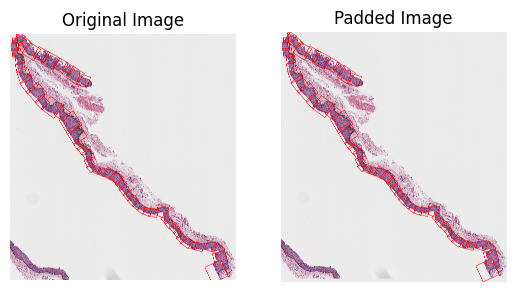

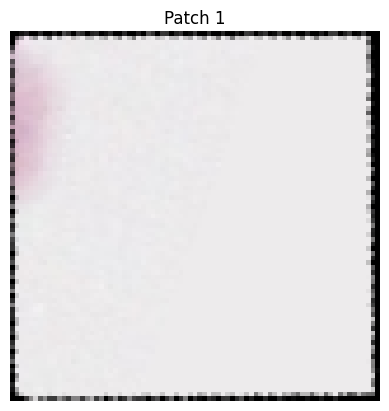

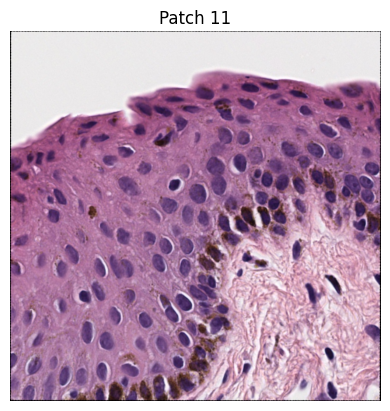

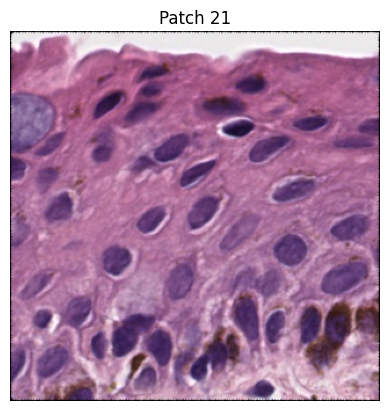

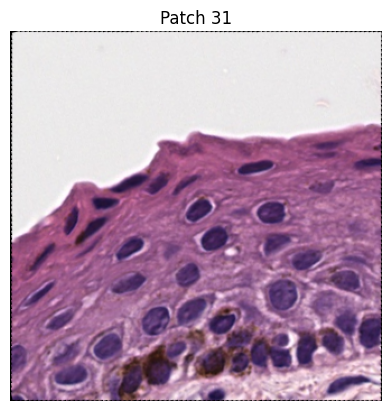

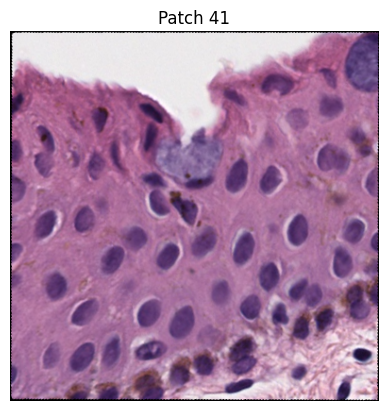

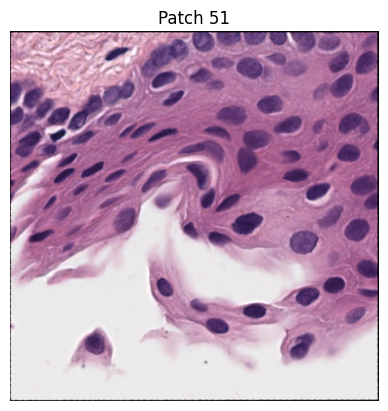

                      Metric        Value
0  total_epithelium_coverage    95.065965
1   background_pixel_percent    10.845231
2                      score    93.883726
3           extension_factor     1.100000
4                  step_size     2.000000
5                  max_width  2048.000000
6          overlap_threshold     0.300000


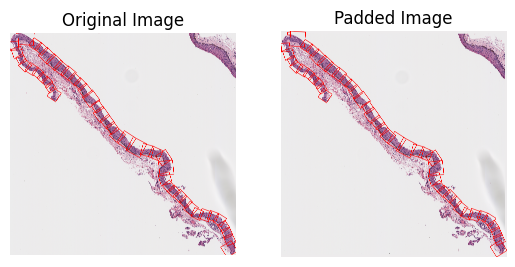

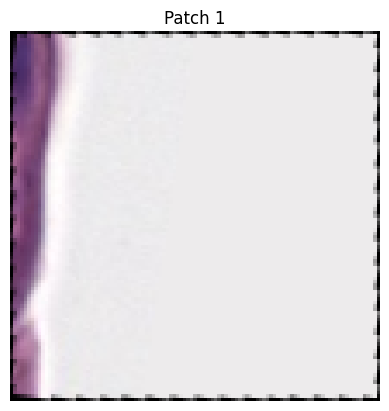

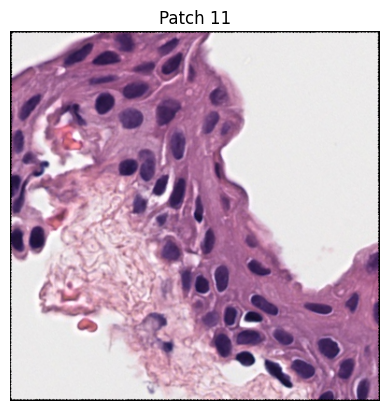

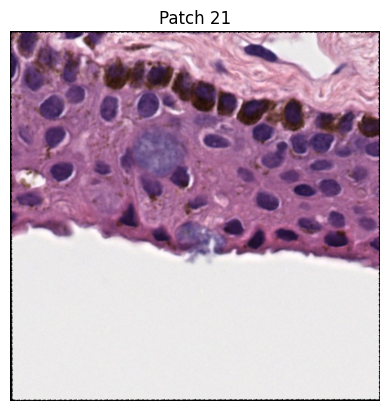

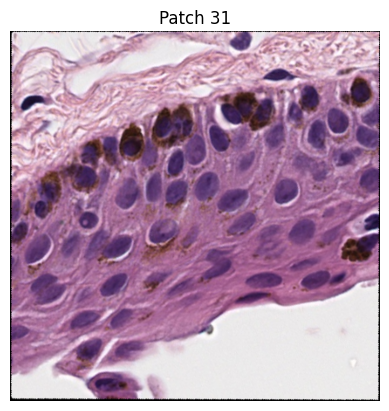

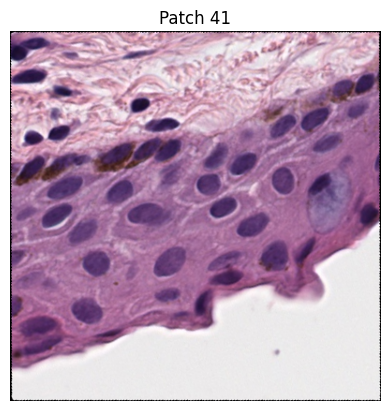

                      Metric        Value
0  total_epithelium_coverage    96.008014
1   background_pixel_percent     7.629560
2                      score    95.280499
3           extension_factor     1.100000
4                  step_size     2.000000
5                  max_width  2048.000000
6          overlap_threshold     0.300000


In [985]:
import os
import re

# Path to your folder
image_folder = "testing_slices" # put folder path here

# Dictionary to store matches
cases = {}

# Iterate over files in the folder
for filename in os.listdir(image_folder):
    match = re.match(r"case_(\d+)_match_(\d+).*\.(png|tif)", filename)
    if match:
        case_number, match_number, extension = match.groups()
        case_number, match_number = int(case_number), int(match_number)  # Convert to int for sorting

        if case_number not in cases:
            cases[case_number] = {}
        
        if match_number not in cases[case_number]:
            cases[case_number][match_number] = {"mask": None, "slice": None}

        if extension == "png":
            cases[case_number][match_number]["mask"] = os.path.join(image_folder, filename)
        elif extension == "tif":
            cases[case_number][match_number]["slice"] = os.path.join(image_folder, filename)


# Build list of tuples (mask, slice), ensuring both exist
matched_pairs = [
    (data["mask"], data["slice"])
    for case in cases.values()
    for data in case.values()
    if data["mask"] and data["slice"]
]

# delete any patches that are already in the directory
empty_folder()

# Run patching and exporting over list of tuples
for m in matched_pairs:
    image1 = cv2.imread(m[0])
    image1_gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    _,whole_thresh1=cv2.threshold(image1_gray,240,255,cv2.THRESH_BINARY_INV)
    metrics, images = patching_export(whole_thresh1, m[0], m[1])  # (binary, slice_name, slice_details) aka (binary image, epithelium annotation png, tif)
    print(metrics)
